In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.experimental import enable_iterative_imputer
from sktime.forecasting.base import ForecastingHorizon
from sklearn.impute import KNNImputer, IterativeImputer
from sktime.forecasting.naive import NaiveForecaster
from etna.models import NaiveModel as EtnaNaive
from etna.datasets import TSDataset
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [48]:
df = pd.read_csv('sunspots.csv', parse_dates=['Month'], index_col='Month')

df.rename(columns={'Sunspots': 'value'}, inplace=True)
df['value'] = df['value'].astype(float)

print(f"Период: {df.index.min()} — {df.index.max()}")
print(f"Всего наблюдений: {len(df)}")
print(f"Частота (инференс): {pd.infer_freq(df.index)}")

Период: 1749-01-01 00:00:00 — 1983-12-01 00:00:00
Всего наблюдений: 2805
Частота (инференс): None


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2805 entries, 1749-01-01 to 1983-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   2805 non-null   float64
dtypes: float64(1)
memory usage: 43.8 KB


In [50]:
df.describe()

,value
count,2805.000000
mean,51.301818
std,43.487735
min,0.000000
25%,15.700000
50%,42.000000
75%,75.000000
max,253.800000


Всего наблюдений после реиндексации: 2820
Частота (инференс): MS
Пропущенных значений: 15


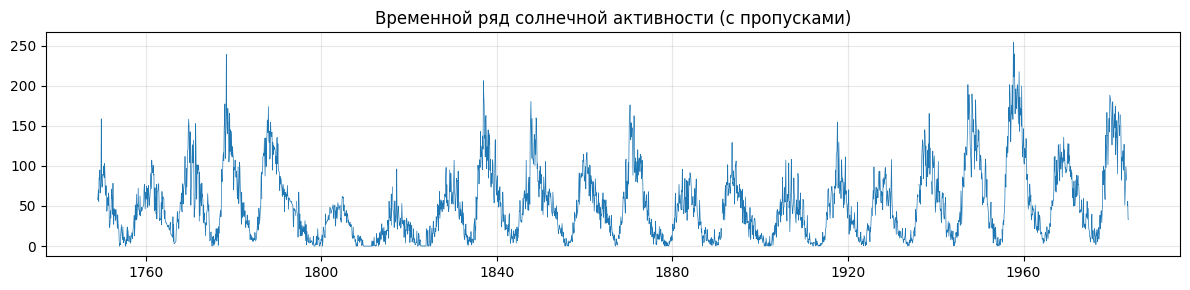

In [51]:
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

df = df.reindex(full_date_range)
df.index.name = 'Month'

print(f"Всего наблюдений после реиндексации: {len(df)}")
print(f"Частота (инференс): {pd.infer_freq(df.index)}")
print(f"Пропущенных значений: {df['value'].isna().sum()}")

plt.figure(figsize=(12, 3))
plt.plot(df.index, df['value'], linewidth=0.5)
plt.title('Временной ряд солнечной активности (с пропусками)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Train: 1749-01-01 00:00:00 — 1936-12-01 00:00:00, n=2256
Test: 1937-01-01 00:00:00 — 1983-12-01 00:00:00, n=564


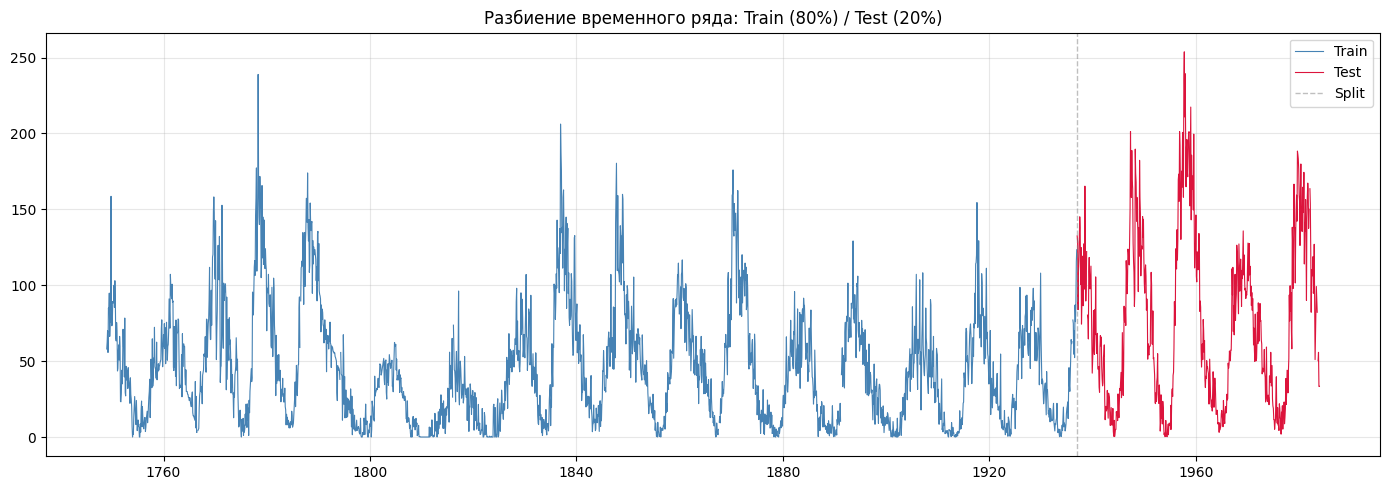

In [52]:
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

print(f"Train: {train_df.index.min()} — {train_df.index.max()}, n={len(train_df)}")
print(f"Test: {test_df.index.min()} — {test_df.index.max()}, n={len(test_df)}")

plt.figure(figsize=(14, 5))
plt.plot(train_df.index, train_df['value'], label='Train', color='steelblue', linewidth=0.8)
plt.plot(test_df.index, test_df['value'], label='Test', color='crimson', linewidth=0.8)
plt.axvline(x=train_df.index[-1], color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Split')
plt.title('Разбиение временного ряда: Train (80%) / Test (20%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
df_filled = df.copy()

df_bfill = df_filled.copy()
df_bfill['value_bfill'] = df_bfill['value'].bfill()

df_ffill = df_filled.copy()
df_ffill['value_ffill'] = df_ffill['value'].ffill()

df_linear = df_filled.copy()
df_linear['value_linear'] = df_linear['value'].interpolate(method='linear')

df_quadratic = df_filled.copy()
df_quadratic['value_quadratic'] = df_quadratic['value'].interpolate(method='quadratic', order=2)

df_mice = df_filled.copy()
imputer_mice = IterativeImputer(random_state=42, max_iter=10)
df_mice['time_idx'] = np.arange(len(df_mice))
df_mice['value_mice'] = imputer_mice.fit_transform(df_mice[['value', 'time_idx']])[:, 0]
df_mice = df_mice.drop(columns=['time_idx'])

df_knn = df_filled.copy()
imputer_knn = KNNImputer(n_neighbors=4)
df_knn['time_idx'] = np.arange(len(df_knn))
df_knn['value_knn'] = imputer_knn.fit_transform(df_knn[['value', 'time_idx']])[:, 0]
df_knn = df_knn.drop(columns=['time_idx'])

results = pd.DataFrame({
    'original': df_filled['value'],
    'bfill': df_bfill['value_bfill'],
    'ffill': df_ffill['value_ffill'],
    'linear': df_linear['value_linear'],
    'quadratic': df_quadratic['value_quadratic'],
    'mice': df_mice['value_mice'],
    'knn': df_knn['value_knn']
})

missing_idx = results['original'].isna()

results[missing_idx][['original', 'bfill', 'ffill', 'linear', 'quadratic', 'mice', 'knn']]

,original,bfill,ffill,linear,quadratic,mice,knn
Month,,,,,,,
1766-08-01,NaN,4.3,3.3,3.80,4.711260,41.472858,3.900
1786-07-01,NaN,89.7,59.0,74.35,62.159000,43.434665,88.125
1794-04-01,NaN,55.7,38.0,46.85,48.660308,44.198045,44.800
1816-02-01,NaN,73.7,26.3,50.00,45.318945,46.348645,55.950
1856-02-01,NaN,0.4,0.5,0.45,-1.685340,50.288674,2.625
1857-12-01,NaN,39.0,31.4,35.20,35.235866,50.469259,36.475
1867-08-01,NaN,9.8,5.0,7.40,7.127919,51.421432,7.450
1890-03-01,NaN,1.6,0.6,1.10,-0.663927,53.645907,3.075
1891-04-01,NaN,41.1,10.4,25.75,22.035694,53.752617,30.500


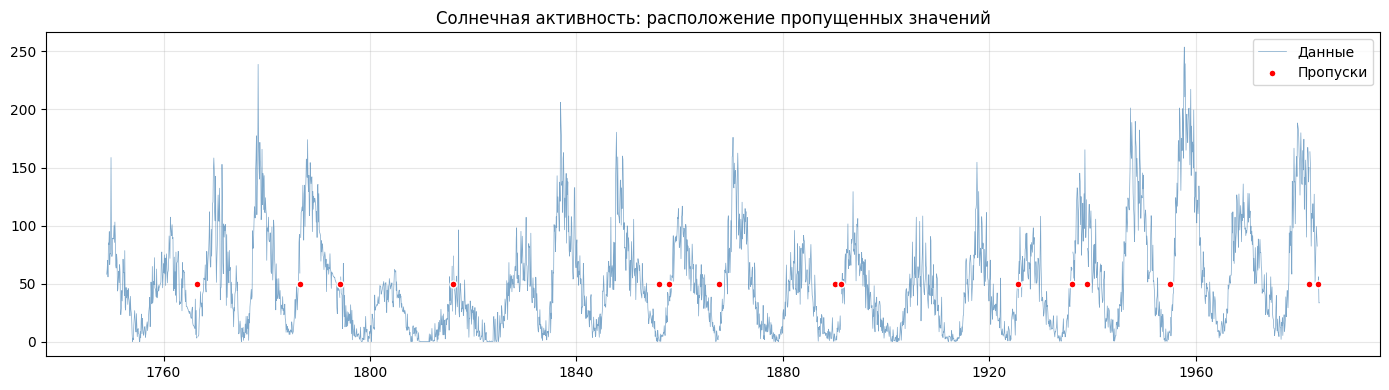

In [54]:
plt.figure(figsize=(14, 4))
plt.plot(results.index, results['original'], label='Данные', color='steelblue', linewidth=0.5, alpha=0.7)
plt.scatter(results.index[missing_idx], [50]*missing_idx.sum(), 
            color='red', s=25, zorder=5, label='Пропуски', edgecolors='white')
plt.title('Солнечная активность: расположение пропущенных значений')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

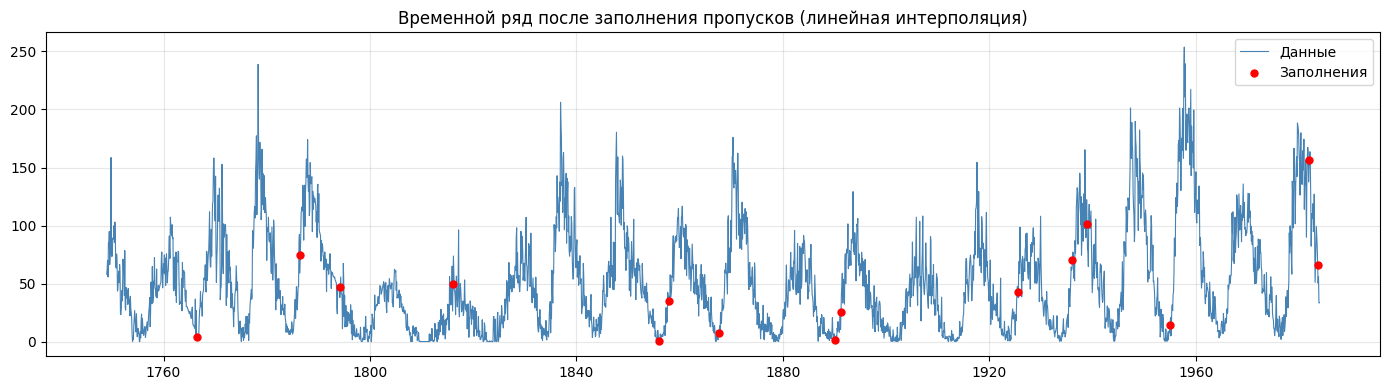

In [55]:
df_clean = df.copy()
df_clean['value'] = df_clean['value'].interpolate(method='linear')

plt.figure(figsize=(14, 4))
plt.plot(df_clean.index, df_clean['value'], label='Данные', color='steelblue', linewidth=0.8)
plt.scatter(df.index[df['value'].isna()], df_clean.loc[df['value'].isna(), 'value'], 
            color='red', s=25, zorder=5, label='Заполнения')
plt.title('Временной ряд после заполнения пропусков (линейная интерполяция)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Найдено выбросов: 41


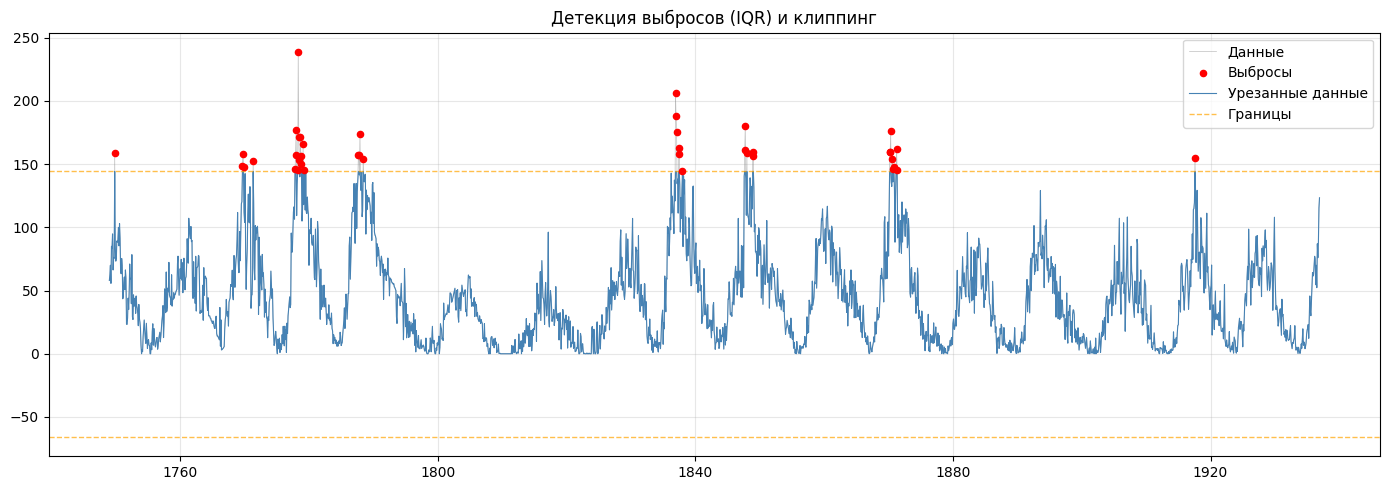

In [56]:
train_clean = train_df.copy()
train_clean['value'] = train_clean['value'].interpolate(method='linear')

Q1 = train_clean['value'].quantile(0.25)
Q3 = train_clean['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_clean[(train_clean['value'] < lower_bound) | (train_clean['value'] > upper_bound)]
print(f"Найдено выбросов: {len(outliers)}")

train_clipped = train_clean.copy()
train_clipped['value'] = train_clipped['value'].clip(lower=lower_bound, upper=upper_bound)

plt.figure(figsize=(14, 5))
plt.plot(train_clean.index, train_clean['value'], label='Данные', color='gray', alpha=0.5, linewidth=0.5)
plt.scatter(outliers.index, outliers['value'], color='red', s=20, zorder=5, label='Выбросы')
plt.plot(train_clipped.index, train_clipped['value'], label='Урезанные данные', color='steelblue', linewidth=0.8)
plt.axhline(y=lower_bound, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Границы')
plt.axhline(y=upper_bound, color='orange', linestyle='--', linewidth=1, alpha=0.7)
plt.title('Детекция выбросов (IQR) и клиппинг')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
train_size = int(len(df_clean) * 0.8)
train_final = train_clipped.copy()
test_final = df_clean.iloc[train_size:].copy()

print(f"Train: {len(train_final)}, Test: {len(test_final)}")

Train: 2256, Test: 564


1 |   20.55
2 |   20.34
3 |   21.49
4 |   26.10
5 |   32.65
6 |   33.47
7 |   36.26
8 |   40.10
9 |   41.57
10 |   43.65
11 |   43.18
12 |   43.31
13 |   47.15
14 |   51.78
15 |   55.74
16 |   58.91
17 |   60.73
18 |   62.78
19 |   66.03
20 |   66.66
21 |   66.74
22 |   68.30
23 |   69.36
24 |   70.65


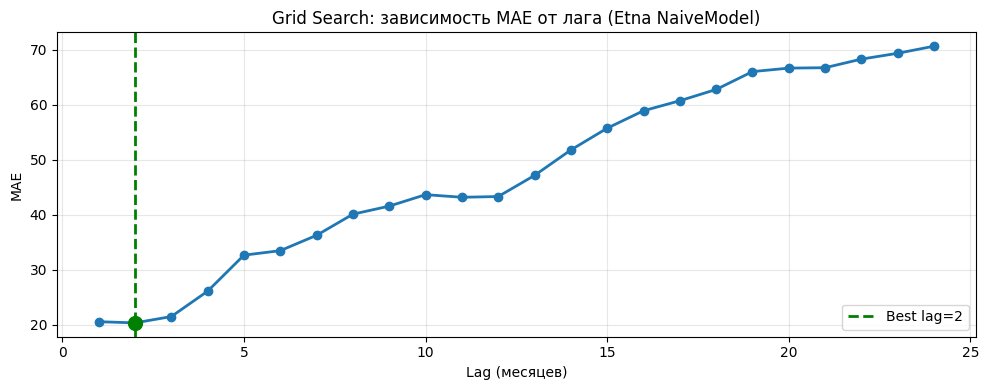

In [58]:
lag_range = range(1, 25)
results = []

for lag in lag_range:
    df_etna = train_final.reset_index()
    df_etna.columns = ['timestamp', 'target']
    df_etna['segment'] = 'sunspots'
    ts_train = TSDataset(df=TSDataset.to_dataset(df_etna), freq='MS')

    model = EtnaNaive(lag=lag)
    model.fit(ts_train)

    ts_pred = model.forecast(ts_train, prediction_size=12)
    pred_values = ts_pred.to_pandas()[('sunspots', 'target')].values

    actual_values = train_final['value'].iloc[-12:].values
    
    mae = mean_absolute_error(actual_values, pred_values)
    results.append({'lag': lag, 'mae': mae})
    
    print(f"{lag} | {mae:>7.2f}")


results_df = pd.DataFrame(results)
best_idx = results_df['mae'].idxmin()
best_lag_etna = results_df.loc[best_idx, 'lag']
best_mae = results_df.loc[best_idx, 'mae']

plt.figure(figsize=(10, 4))
plt.plot(results_df['lag'], results_df['mae'], 'o-', linewidth=2, markersize=6)
plt.axvline(x=best_lag_etna, color='green', linestyle='--', linewidth=2, label=f'Best lag={best_lag_etna}')
plt.scatter([best_lag_etna], [best_mae], color='green', s=100, zorder=5)
plt.title('Grid Search: зависимость MAE от лага (Etna NaiveModel)')
plt.xlabel('Lag (месяцев)')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

last | 1 | 20.55
last | 2 | 20.34
last | 3 | 21.49
last | 4 | 26.10
last | 5 | 32.65
last | 6 | 33.47
last | 7 | 36.26
last | 8 | 40.10
last | 9 | 41.57
last | 10 | 43.65
last | 11 | 43.18
last | 12 | 43.31
last | 13 | 47.15
last | 14 | 51.78
last | 15 | 55.74
last | 16 | 58.91
last | 17 | 60.73
last | 18 | 62.78
last | 19 | 66.03
last | 20 | 66.66
last | 21 | 66.74
last | 22 | 68.30
last | 23 | 69.36
last | 24 | 70.65
mean | 1 | 35.22
mean | 2 | 35.22
mean | 3 | 35.22
mean | 4 | 35.22
mean | 5 | 35.25
mean | 6 | 35.22
mean | 7 | 35.24
mean | 8 | 35.17
mean | 9 | 35.32
mean | 10 | 35.36
mean | 11 | 35.23
mean | 12 | 35.22
mean | 13 | 35.22
mean | 14 | 35.00
mean | 15 | 35.29
mean | 16 | 35.25
mean | 17 | 35.67
mean | 18 | 35.42
mean | 19 | 35.22
mean | 20 | 35.42
mean | 21 | 35.02
mean | 22 | 35.38
mean | 23 | 35.30
mean | 24 | 35.35
drift | 1 | 20.55
drift | 2 | 20.55
drift | 3 | 20.55
drift | 4 | 20.55
drift | 5 | 20.55
drift | 6 | 20.55
drift | 7 | 20.55
drift | 8 | 20.55
drift | 9 

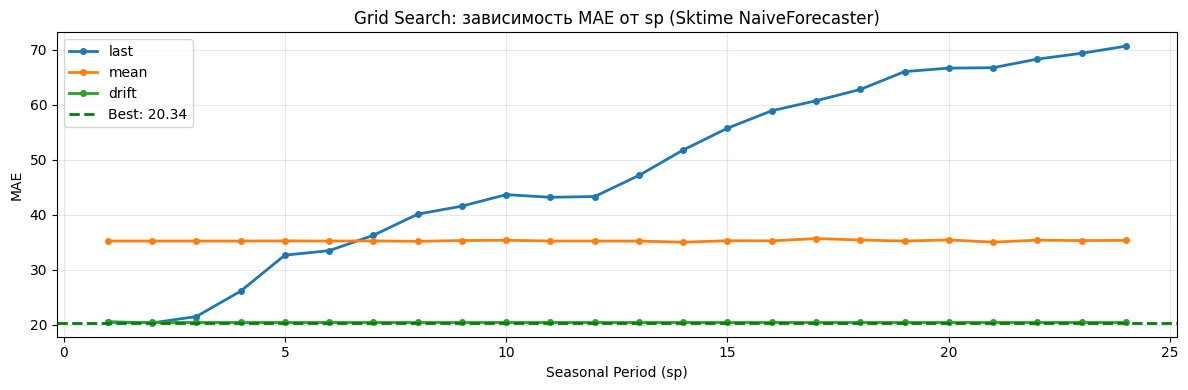

In [59]:
y_train = train_final['value'].reset_index(drop=True)

strategies = ['last', 'mean', 'drift']
sp_range = range(1, 25)

results_sktime = []

for strategy in strategies:
    for sp in sp_range:
        model = NaiveForecaster(strategy=strategy, sp=sp)

        train_sub = y_train.iloc[:-12]
        val_sub = y_train.iloc[-12:]
        
        fh = ForecastingHorizon(np.arange(1, 13), is_relative=True)
        model.fit(train_sub)
        pred = model.predict(fh)
        
        mae = mean_absolute_error(val_sub.values, pred.values)
        results_sktime.append({'strategy': strategy, 'sp': sp, 'mae': mae})
        
        print(f"{strategy} | {sp} | {mae:.2f}")


results_sktime_df = pd.DataFrame(results_sktime)
best_idx = results_sktime_df['mae'].idxmin()
best_strategy = results_sktime_df.loc[best_idx, 'strategy']
best_sp = int(results_sktime_df.loc[best_idx, 'sp'])
best_mae_sktime = results_sktime_df.loc[best_idx, 'mae']

plt.figure(figsize=(12, 4))
for strategy in strategies:
    subset = results_sktime_df[results_sktime_df['strategy'] == strategy]
    plt.plot(subset['sp'], subset['mae'], 'o-', label=strategy, linewidth=2, markersize=4)

plt.axhline(y=best_mae_sktime, color='green', linestyle='--', linewidth=2, label=f'Best: {best_mae_sktime:.2f}')
plt.title('Grid Search: зависимость MAE от sp (Sktime NaiveForecaster)')
plt.xlabel('Seasonal Period (sp)')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
df_etna = train_final.reset_index()
df_etna.columns = ['timestamp', 'target']
df_etna['segment'] = 'sunspots'
ts_train = TSDataset(df=TSDataset.to_dataset(df_etna), freq='MS')

model_etna = EtnaNaive(best_lag_etna)
model_etna.fit(ts_train)

ts_pred_etna = model_etna.forecast(ts_train, prediction_size=len(test_final))
pred_etna = ts_pred_etna.to_pandas()[('sunspots', 'target')].reset_index(drop=True)

y_train_reset = train_final['value'].reset_index(drop=True)
y_test_reset = test_final['value'].reset_index(drop=True)

fh = ForecastingHorizon(np.arange(1, len(test_final)+1), is_relative=True)
model_sktime = NaiveForecaster(strategy=best_strategy, sp=best_sp)
model_sktime.fit(y_train_reset)
pred_sktime = model_sktime.predict(fh).reset_index(drop=True)

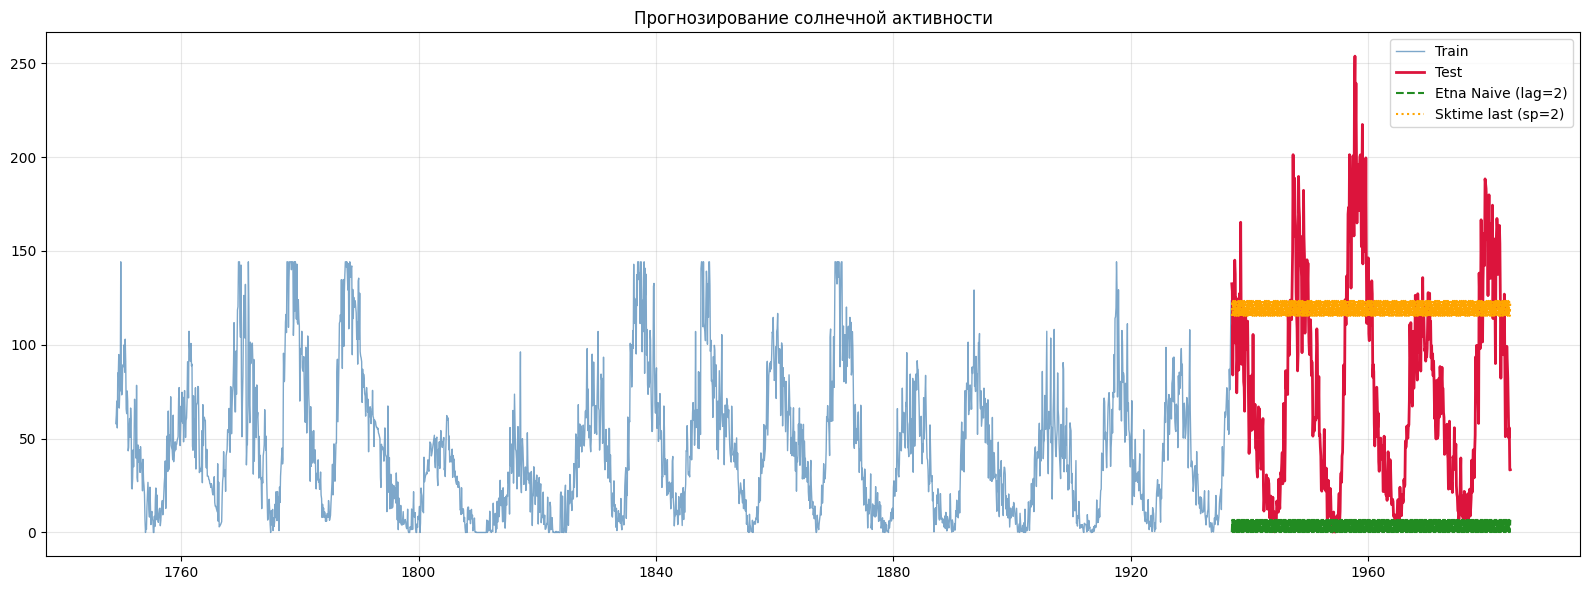

Метрика            Etna       Sktime
MAE               74.45        59.08
RMSE              92.54        69.17


In [61]:
plt.figure(figsize=(16, 6))

plt.plot(train_final.index, train_final['value'], 
         label='Train', color='steelblue', linewidth=1, alpha=0.7)
plt.plot(test_final.index, test_final['value'], 
         label='Test', color='crimson', linewidth=2)
plt.plot(test_final.index, pred_etna.values, 
         label=f'Etna Naive (lag={best_lag_etna})', color='forestgreen', linestyle='--', linewidth=1.5)
plt.plot(test_final.index, pred_sktime.values, 
         label=f'Sktime {best_strategy} (sp={best_sp})', color='orange', linestyle=':', linewidth=1.5)

plt.title('Прогнозирование солнечной активности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mae_etna = mean_absolute_error(y_test_reset, pred_etna)
mae_sktime = mean_absolute_error(y_test_reset, pred_sktime)

rmse_etna = np.sqrt(mean_squared_error(y_test_reset, pred_etna))
rmse_sktime = np.sqrt(mean_squared_error(y_test_reset, pred_sktime))

print(f"{'Метрика':<10} {'Etna':>12} {'Sktime':>12}")
print(f"{'MAE':<10} {mae_etna:>12.2f} {mae_sktime:>12.2f}")
print(f"{'RMSE':<10} {rmse_etna:>12.2f} {rmse_sktime:>12.2f}")